#Ejercicio 3 Series de Tiempo

##Moran Sanchez Gerardo Jasel

#1. Exploracion de Datos
### Cargar y explorar el dataset histórico del valor del dólar frente al peso.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import kpss

In [ ]:
df_Dolar = pd.read_excel('Dolar.xlsx', header=17, names=['Fecha', 'Precio_Dolar'], index_col= 'Fecha')
df_Dolar

/usr/local/lib/python3.10/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Precio_Dolar
Fecha,
2000-04-18,9.4388
2000-04-19,9.3939
2000-04-24,9.4443
2000-04-25,9.4078
2000-04-26,9.4073
...,...
2024-11-05,20.2695
2024-11-06,20.3093
2024-11-07,19.8277


###Visualizar el comportamiento de la serie de tiempo a través de gráficos.


<Figure size 1200x800 with 0 Axes>

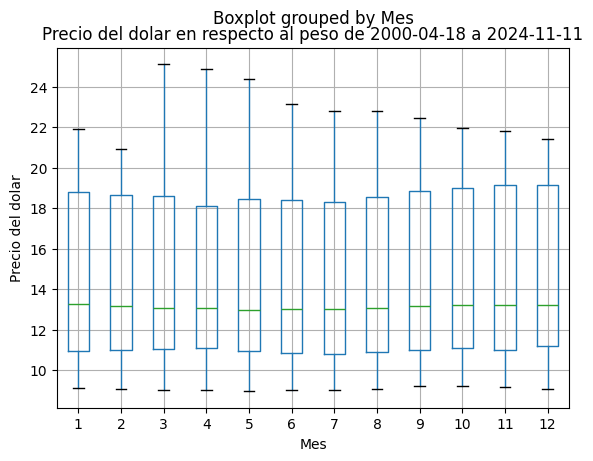

In [ ]:
df_Dolar['Mes']=df_Dolar.index.month
plt.figure(figsize=(12,8))
df_Dolar.boxplot(column="Precio_Dolar",by="Mes")
plt.xlabel("Mes")
plt.ylabel("Precio del dolar")
plt.title("Precio del dolar en respecto al peso de 2000-04-18 a 2024-11-11")
plt.show()

#2. Análisis Estacional y de Tendencia
###Descomponer la serie de tiempo para analizar sus componentes: tendencia, estacionalidad y ruido.

In [ ]:
#pruena de estacionalidad
Dolar_series = df_Dolar['Precio_Dolar']
statistics, p_value, lags, critical_values = kpss(Dolar_series, regression='c', nlags = 'auto')
print(f"Los estadísticos: {statistics}")
print(f"p_values: {p_value}")
print(f"lags: {lags}")
print(f"critical values: {critical_values}")
if p_value < 0.5:
   print("La serie no es estacionaria")
else:
   print("la serie es estacionaria")

Los estadísticos: 12.017154640600838
p_values: 0.01
lags: 45
critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
La serie no es estacionaria


<ipython-input-189-783d2d7e69e4>:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  statistics, p_value, lags, critical_values = kpss(Dolar_series, regression='c', nlags = 'auto')


In [ ]:
Dolar_series_diff = Dolar_series.diff().dropna()
statistics_diff, p_value_diff, lags_diff, critical_values_diff = kpss(Dolar_series_diff, regression='c', nlags = 'auto')
print(f"Los estadísticos: {statistics_diff}")
print(f"p_values: {p_value_diff}")
print(f"lags: {lags_diff}")
print(f"critical values: {critical_values_diff}")
if p_value_diff < 0.5:
   print("La serie no es estacionaria")
else:
   print("la serie es estacionaria")

Los estadísticos: 0.03463478390531385
p_values: 0.1
lags: 6
critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
La serie no es estacionaria


<ipython-input-190-1af1b5872391>:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistics_diff, p_value_diff, lags_diff, critical_values_diff = kpss(Dolar_series_diff, regression='c', nlags = 'auto')


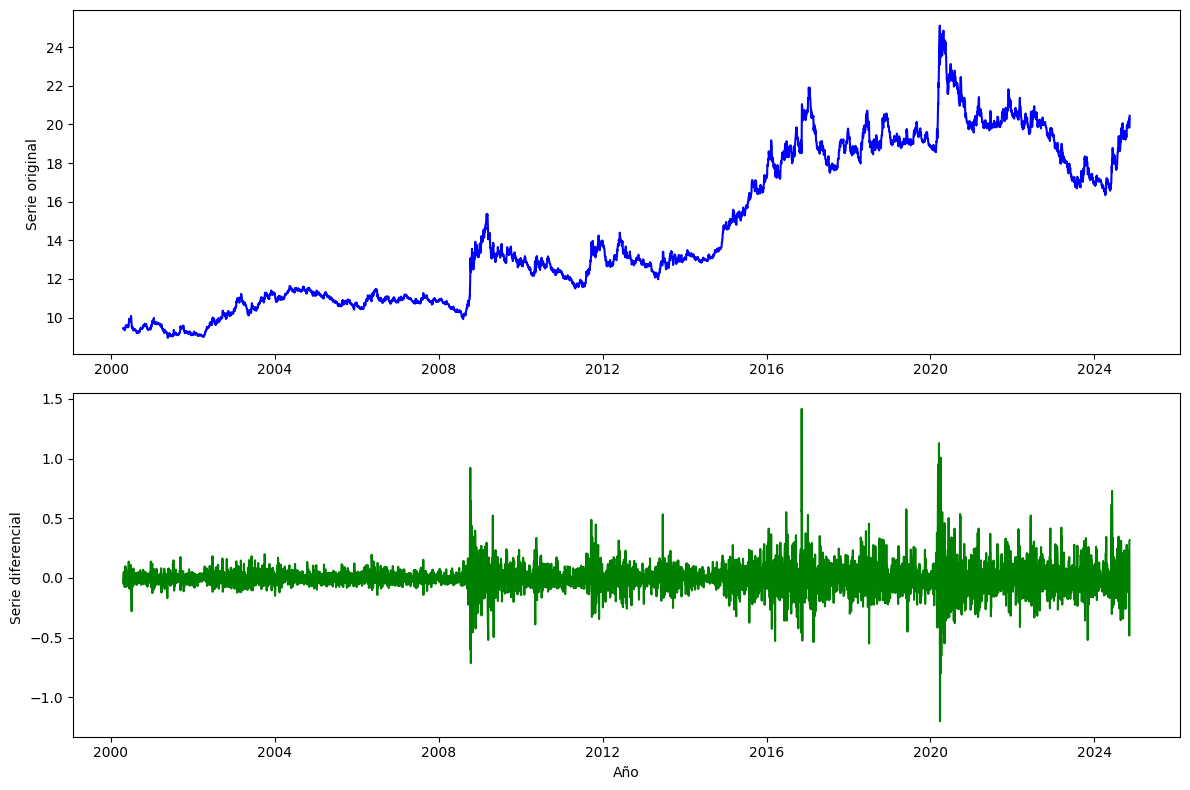

In [ ]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plt.plot(Dolar_series, color="blue")
plt.ylabel("Serie original ")
plt.subplot(212)
plt.plot(Dolar_series_diff, color="green")
plt.ylabel("Serie diferencial ")#ld
plt.xlabel("Año")
plt.tight_layout()
plt.show()

###tendencia, estacionalidad y ruido.

<Figure size 1200x800 with 0 Axes>

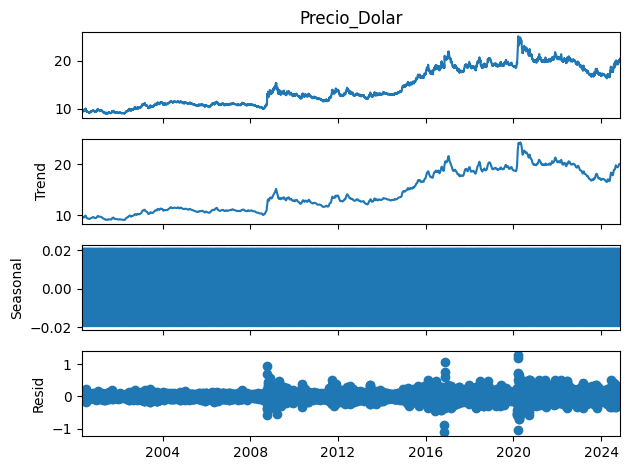

In [ ]:
plt.figure(figsize=(12,8))
decomposition = seasonal_decompose(df_Dolar['Precio_Dolar'], model='additive', period=12)
decomposition.plot()
plt.show()

###Evaluar la presencia de estacionalidad en diferentes periodos
### - Anual (ciclo de 12 meses)
### - Sexenal (ciclo de 6 años)
### - Cuatrienal (ciclo de 4 años)

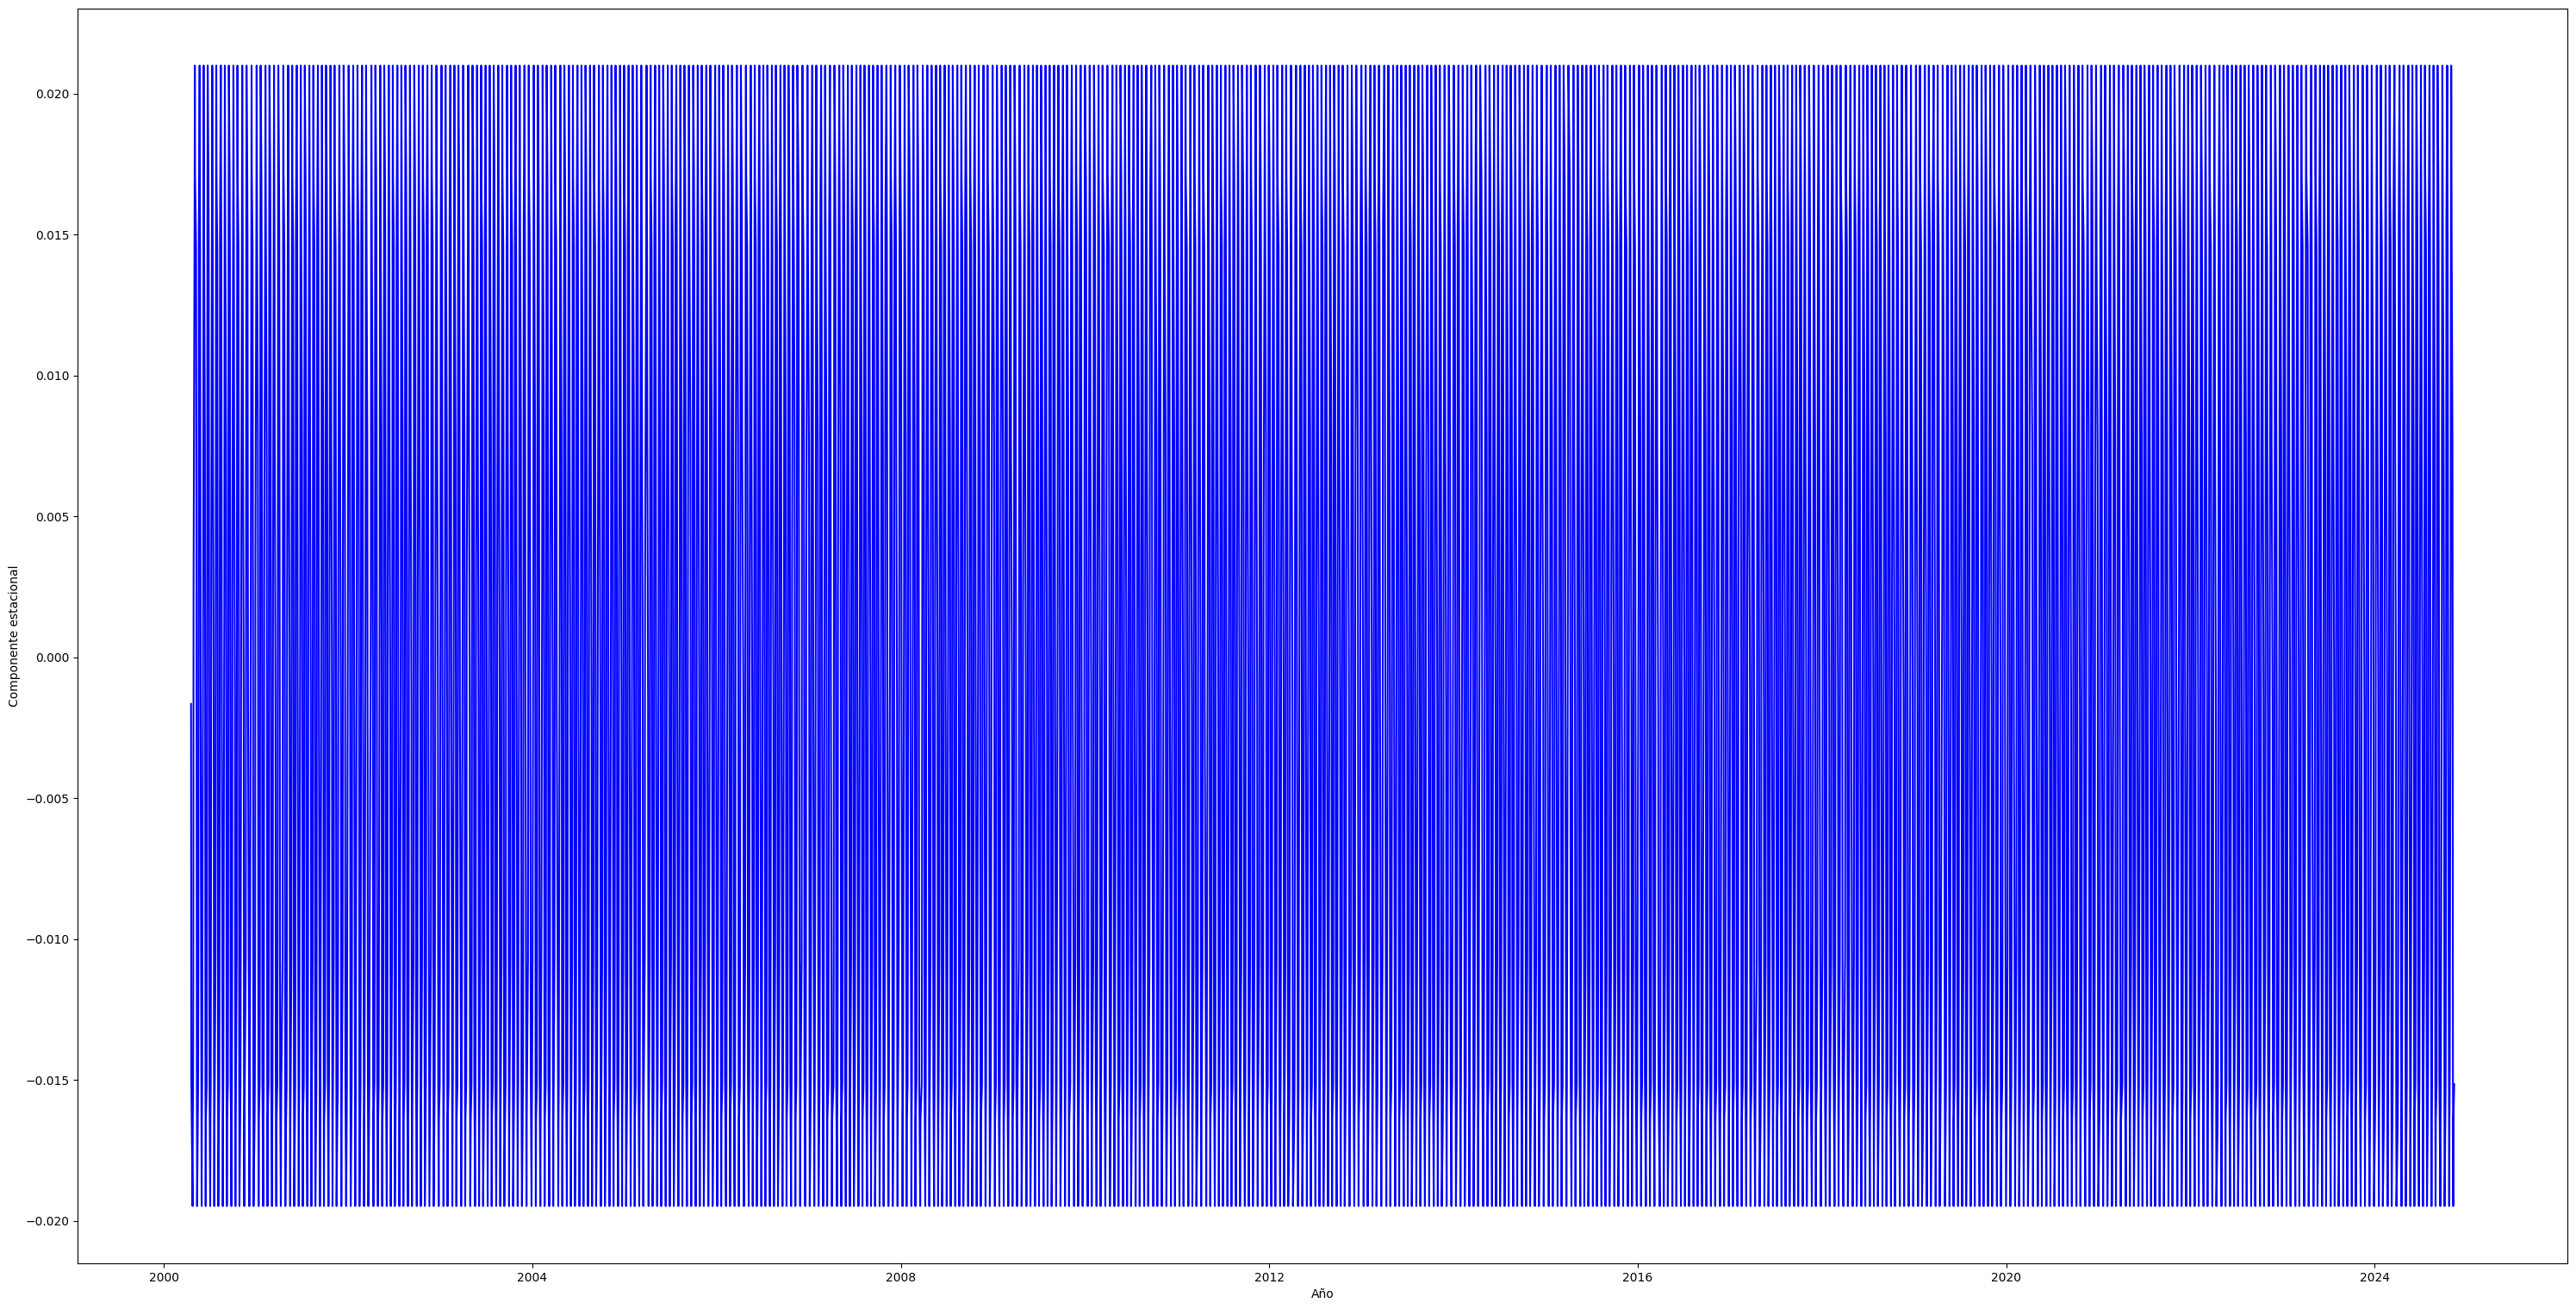

In [ ]:
#Anual
decomposition = seasonal_decompose(df_Dolar['Precio_Dolar'], model='additive', period=12)
plt.figure(figsize=(30,30))
plt.subplot(211)
plt.plot(decomposition.seasonal, color="blue")
plt.ylabel("Componente estacional")
plt.xlabel("Año")
plt.tight_layout()
plt.show()

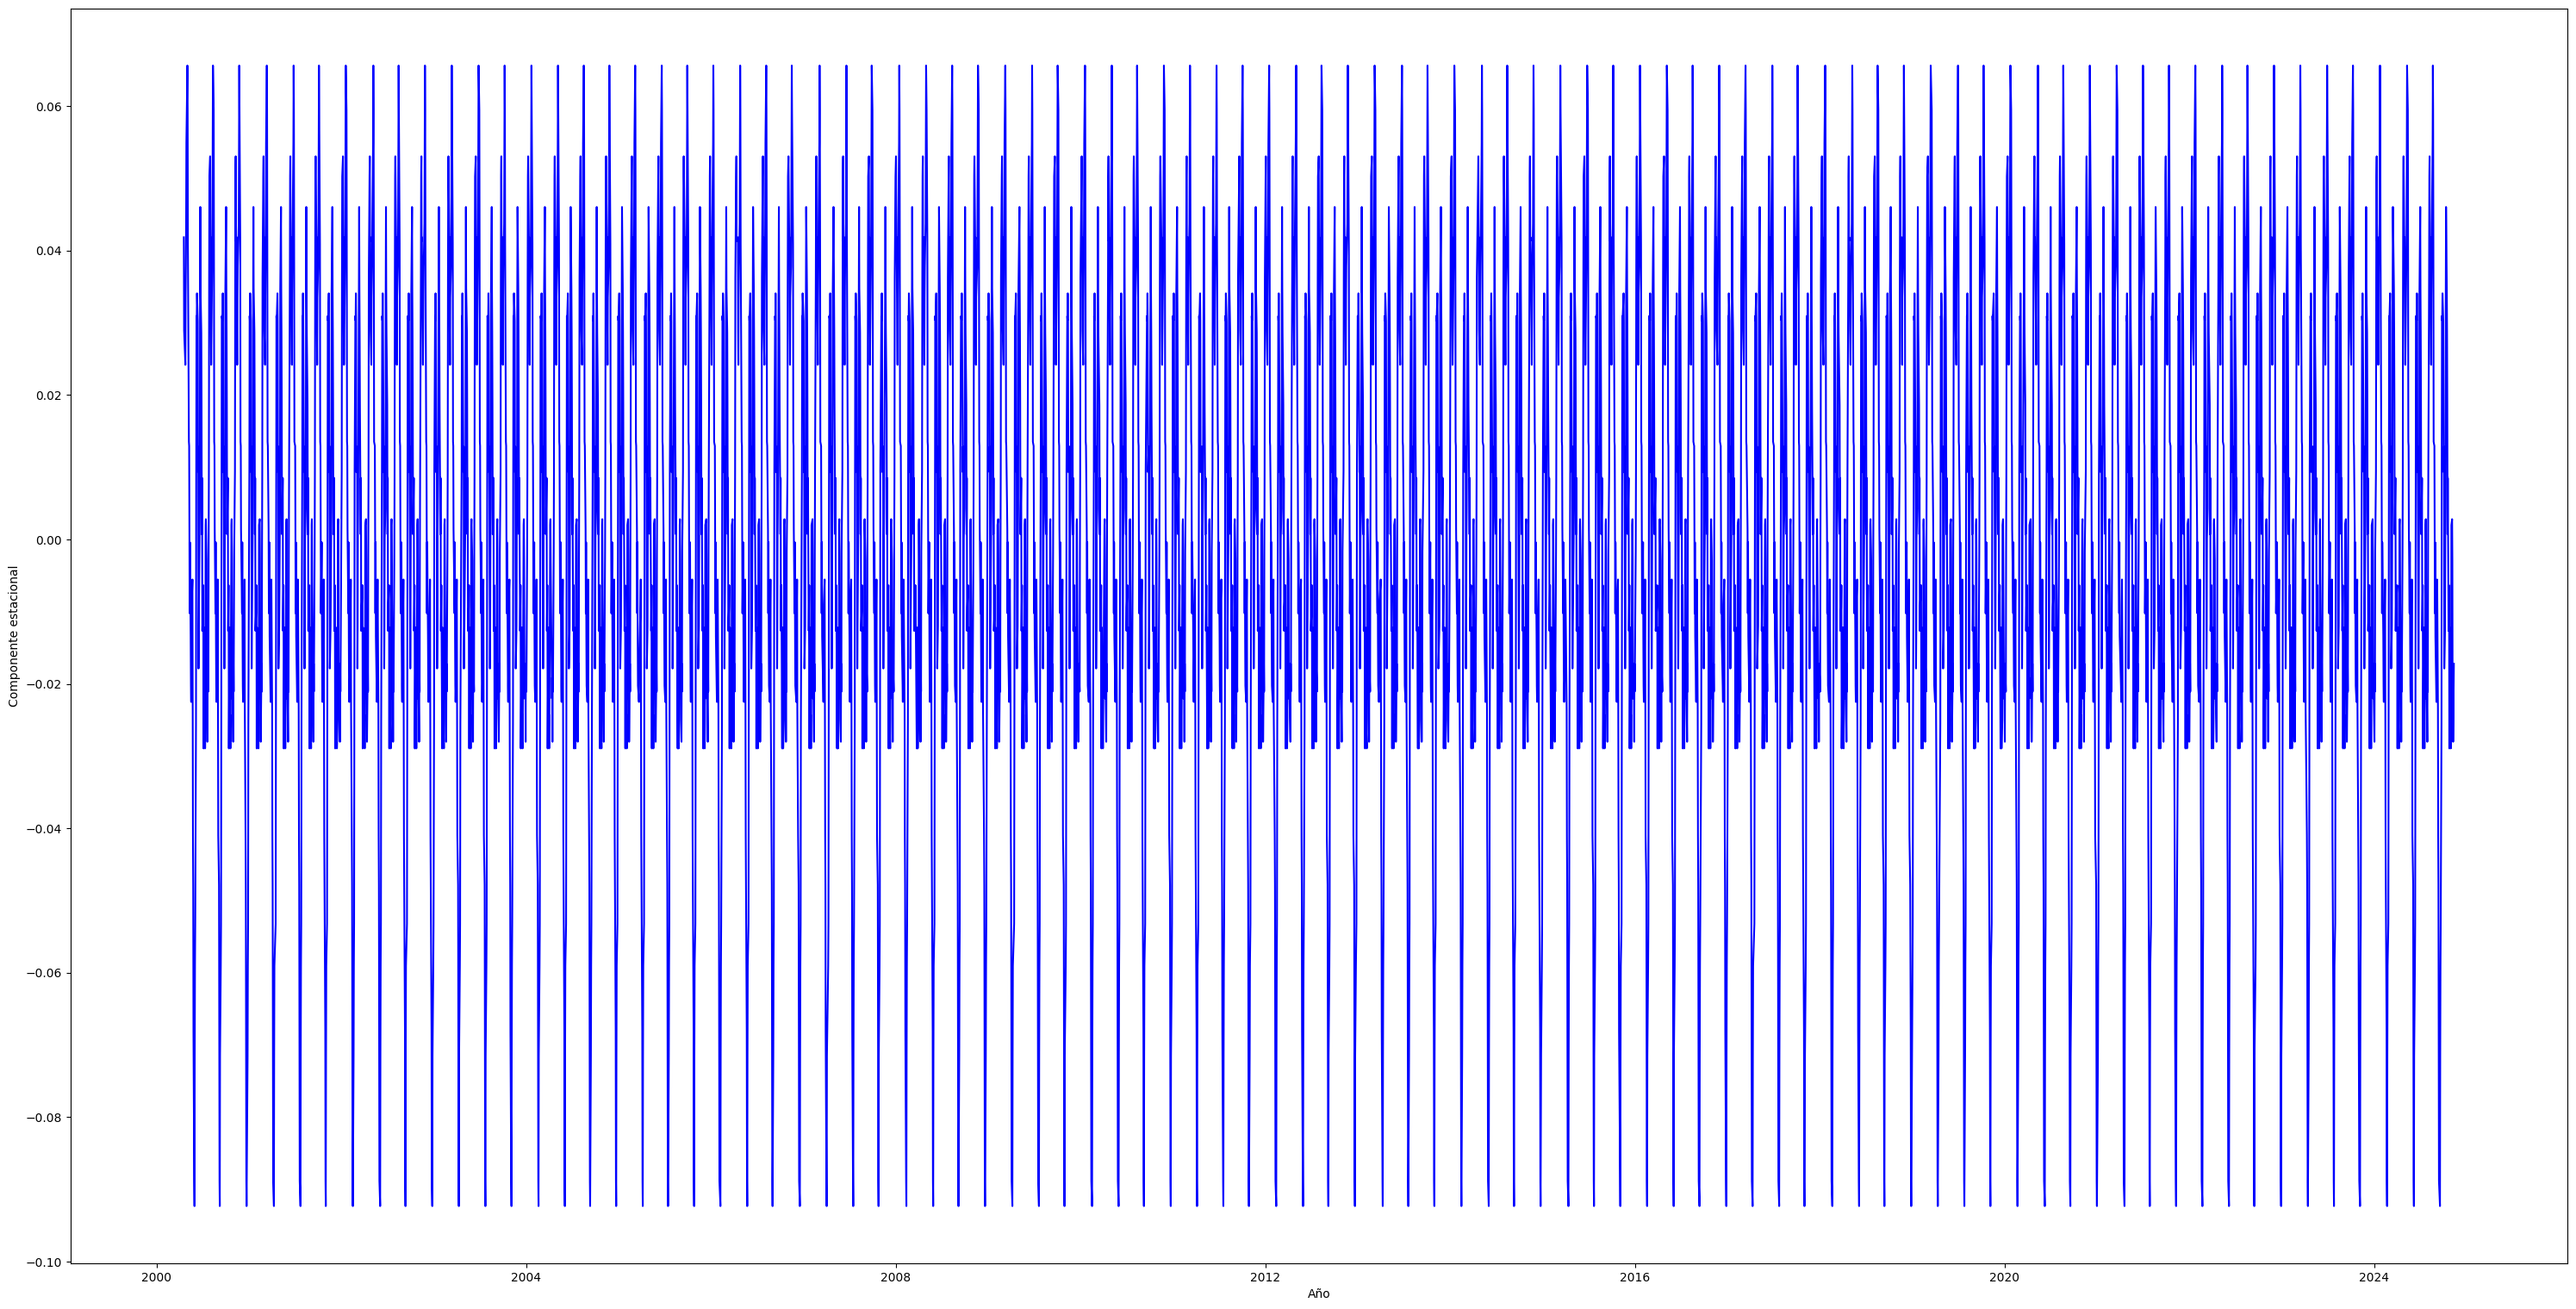

In [ ]:
#Sexenal
decomposition = seasonal_decompose(df_Dolar['Precio_Dolar'], model='additive', period=72)
plt.figure(figsize=(30,30))
plt.subplot(211)
plt.plot(decomposition.seasonal, color="blue")
plt.ylabel("Componente estacional")
plt.xlabel("Año")
plt.tight_layout()
plt.show()

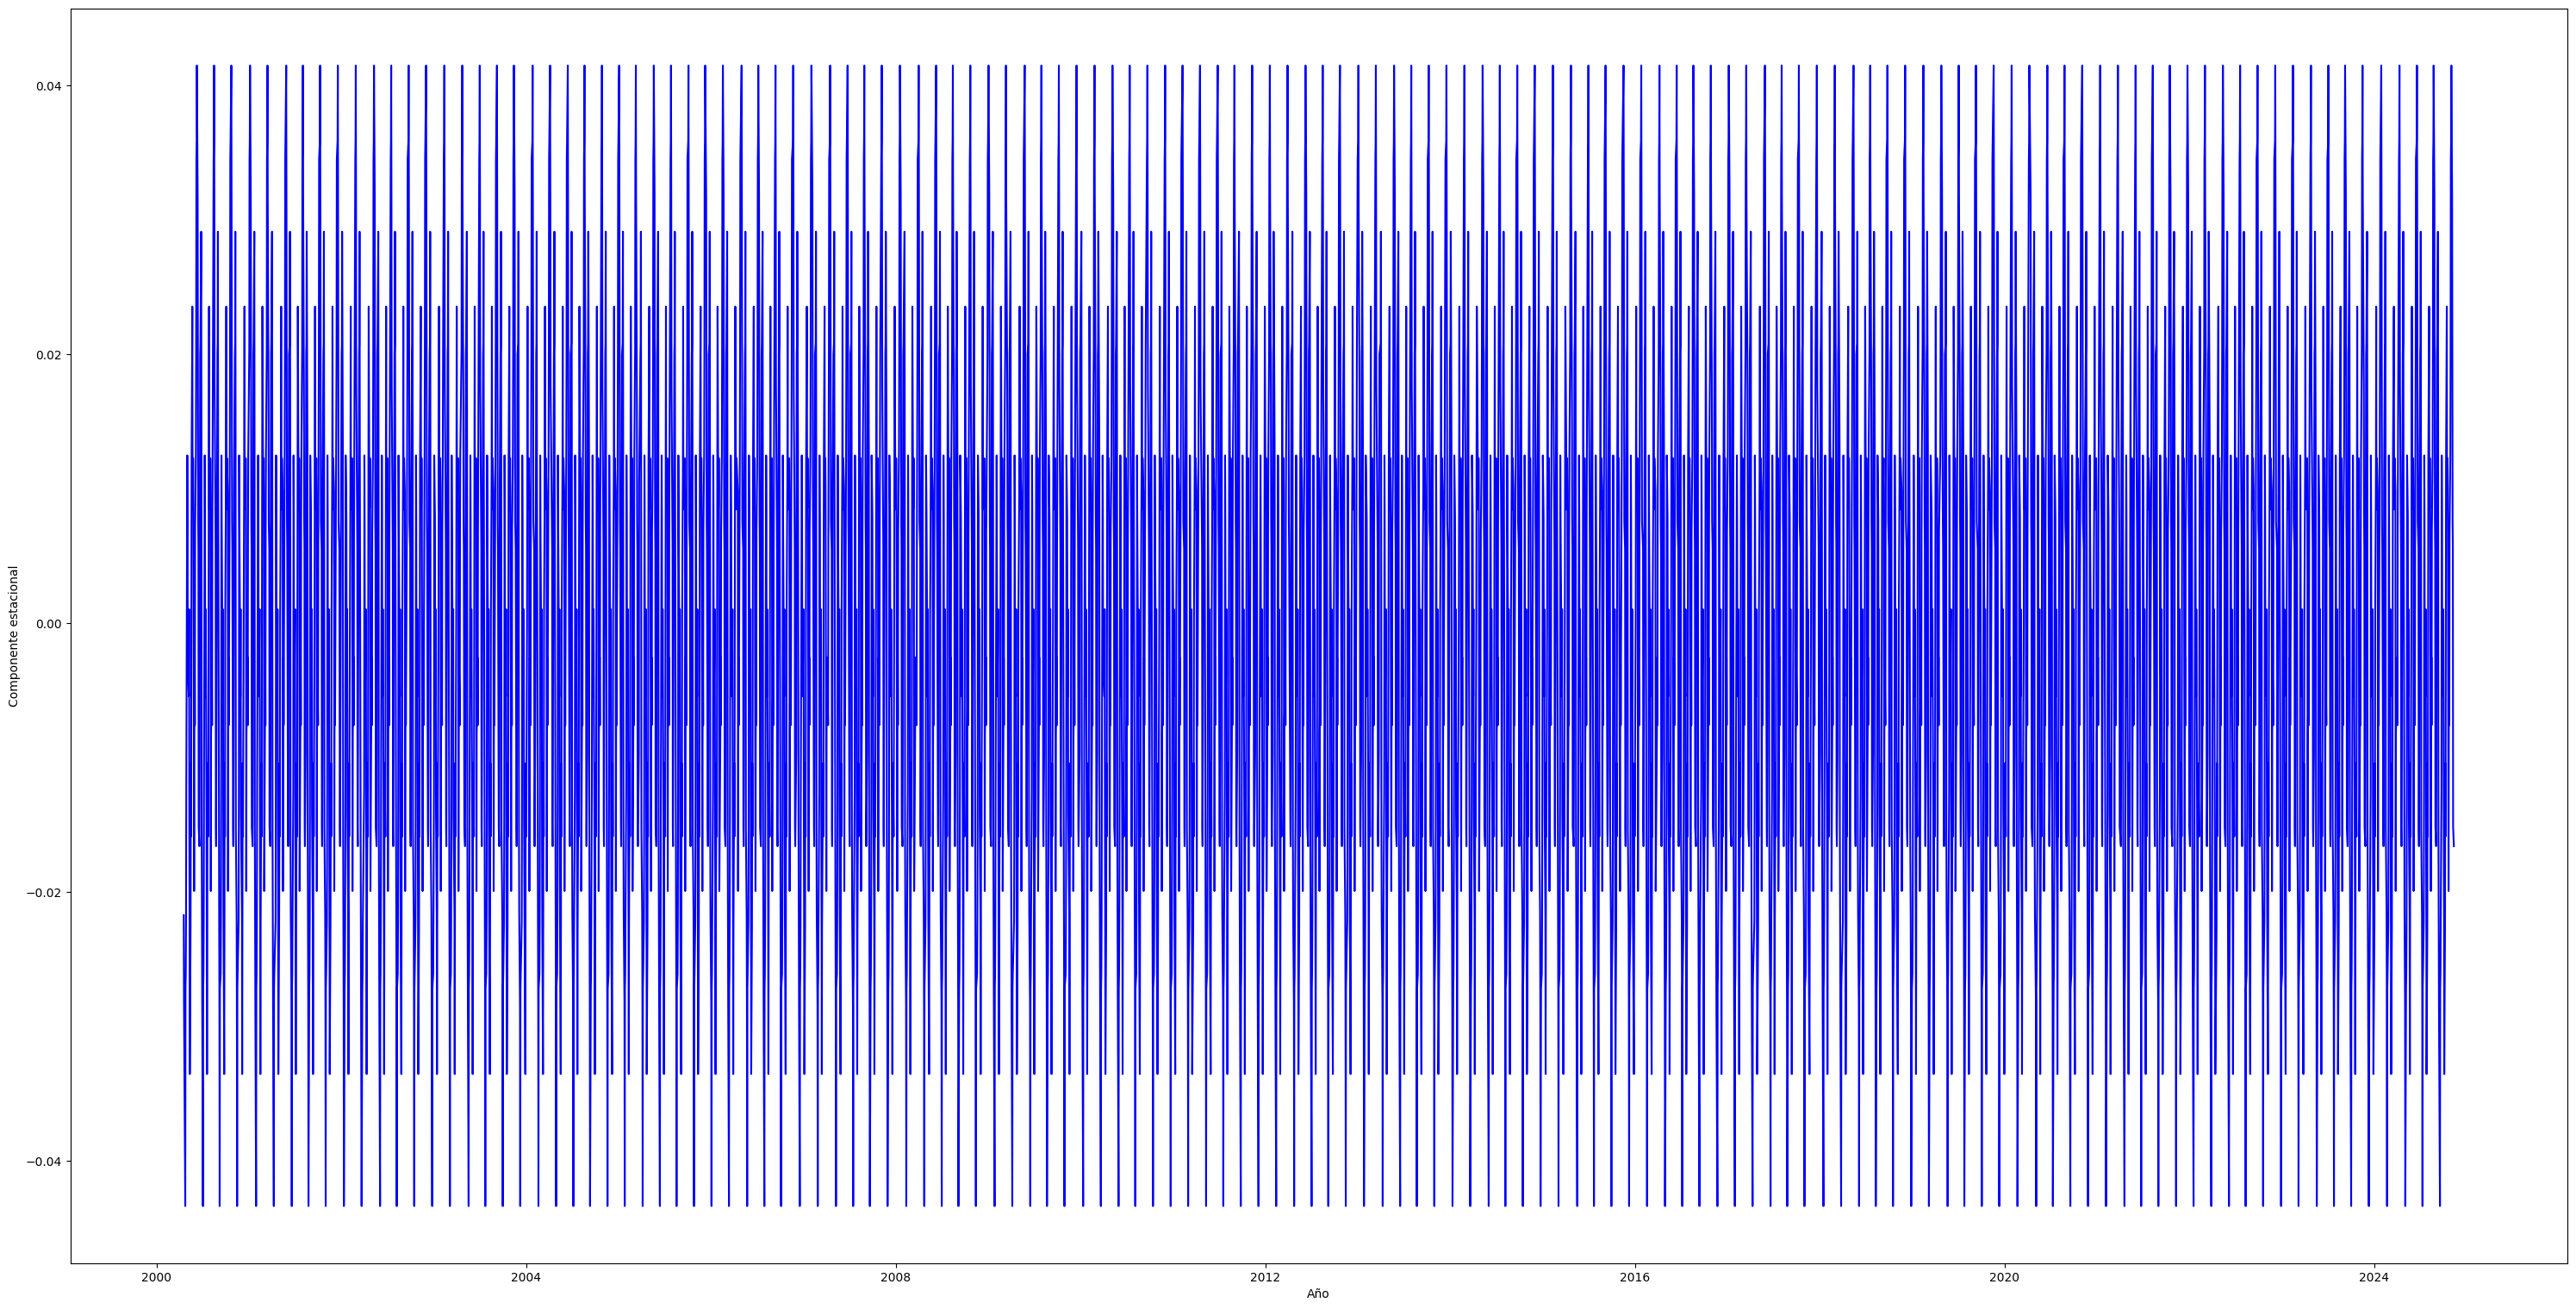

In [ ]:
#Cuatrienal
decomposition = seasonal_decompose(df_Dolar['Precio_Dolar'], model='additive', period=48)
plt.figure(figsize=(30,30))
plt.subplot(211)
plt.plot(decomposition.seasonal, color="blue")
plt.ylabel("Componente estacional")
plt.xlabel("Año")
plt.tight_layout()
plt.show()

#3. Modelado y Predicción
###Probar diferentes modelos de series de tiempo, como ARIMA y SARIMA para realizar predicciones a corto y largo plazo.

In [ ]:
# Ajustar una serie de tiempo por el componente de estacionalidad
#Se resta el componente estacionsl de la serie y se calcula el diferencial

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.tools import diff
Dolar_ts = pd.Series(df_Dolar['Precio_Dolar'].values, index = pd.date_range('2000-04-18', periods = len(df_Dolar)))
decomposition = seasonal_decompose(Dolar_ts, model='additive')
seasonally_adjusted = Dolar_ts - decomposition.seasonal
stationary_series = diff(seasonally_adjusted, k_diff=1)
stationary_series

,0
2000-04-19,-0.043848
2000-04-20,0.053649
2000-04-21,-0.038206
2000-04-22,0.003132
2000-04-23,0.045106
...,...
2017-03-20,0.228269
2017-03-21,0.037797
2017-03-22,-0.480548
2017-03-23,0.308749


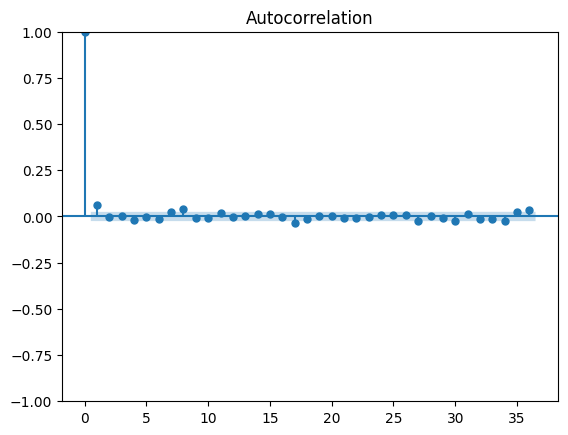

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(stationary_series.dropna(),lags=36)       #lags son as veces ue van a comparar, al inicio es uno porque no hay con que comparar
plt.show()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
model= ARIMA(stationary_series, order=(1,1,1))
fitARIMA = model.fit()
print(fitARIMA.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 6184
Model:                 ARIMA(1, 1, 1)   Log Likelihood                4618.612
Date:                Sat, 16 Nov 2024   AIC                          -9231.224
Time:                        03:52:57   BIC                          -9211.036
Sample:                    04-19-2000   HQIC                         -9224.224
                         - 03-24-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0630      0.005     12.554      0.000       0.053       0.073
ma.L1         -0.9998      0.001  -1166.328      0.000      -1.001      -0.998
sigma2         0.0131   7.92e-05    165.813      0.0

In [ ]:
#Predecir los valores futuros
nperiodos = 3650 #Hasta 10 años
forecasted_values = fitARIMA.get_forecast(steps=nperiodos)

#obtener la media de las predicciones
predicted_mean = forecasted_values.predicted_mean

#obtener los ntervalos de confianza de las predicciones
conf_int = forecasted_values.conf_int()

print("Predicciones")
print(predicted_mean)
print("Intervalos de onfianza")
print(conf_int)


Predicciones
2017-03-25    0.021578
2017-03-26    0.003064
2017-03-27    0.001897
2017-03-28    0.001823
2017-03-29    0.001819
                ...   
2027-03-18    0.001818
2027-03-19    0.001818
2027-03-20    0.001818
2027-03-21    0.001818
2027-03-22    0.001818
Freq: D, Name: predicted_mean, Length: 3650, dtype: float64
Intervalos de onfianza
             lower y   upper y
2017-03-25 -0.202974  0.246130
2017-03-26 -0.221938  0.228065
2017-03-27 -0.223107  0.226900
2017-03-28 -0.223180  0.226827
2017-03-29 -0.223185  0.226822
...              ...       ...
2027-03-18 -0.223207  0.226844
2027-03-19 -0.223207  0.226844
2027-03-20 -0.223207  0.226844
2027-03-21 -0.223207  0.226844
2027-03-22 -0.223207  0.226844

[3650 rows x 2 columns]


In [ ]:
#Mostrar los valorres predichos en  el nivel original
last_values = Dolar_ts.iloc[-1]

#revrtir la diferencia
prediction_csum = predicted_mean.cumsum()
prediction_level = last_values + prediction_csum
print("Valores predichos")
print(prediction_level)

#Revertir la diferenciacion de los iontervalos de confianza
lower_bound = conf_int.iloc[:, 0].cumsum() + last_values
upper_bound = conf_int.iloc[:,1].cumsum() + last_values

#Crear un DF con los intervalos  en valor real
conf_int_ori= pd.concat([lower_bound, upper_bound], axis=1)
conf_int_ori.columns = [["lower_bound", "upper_bound"]]

print("Intervalos de confianza")
print(conf_int_ori)

Valores predichos
2017-03-25    20.471778
2017-03-26    20.474842
2017-03-27    20.476739
2017-03-28    20.478562
2017-03-29    20.480381
                ...    
2027-03-18    27.101003
2027-03-19    27.102822
2027-03-20    27.104640
2027-03-21    27.106459
2027-03-22    27.108277
Freq: D, Name: predicted_mean, Length: 3650, dtype: float64
Intervalos de confianza
           lower_bound upper_bound
2017-03-25   20.247226   20.696330
2017-03-26   20.025288   20.924396
2017-03-27   19.802182   21.151296
2017-03-28   19.579001   21.378123
2017-03-29   19.355817   21.604945
...                ...         ...
2027-03-18 -793.301474  847.503481
2027-03-19 -793.524681  847.730324
2027-03-20 -793.747888  847.957168
2027-03-21 -793.971095  848.184012
2027-03-22 -794.194302  848.410856

[3650 rows x 2 columns]


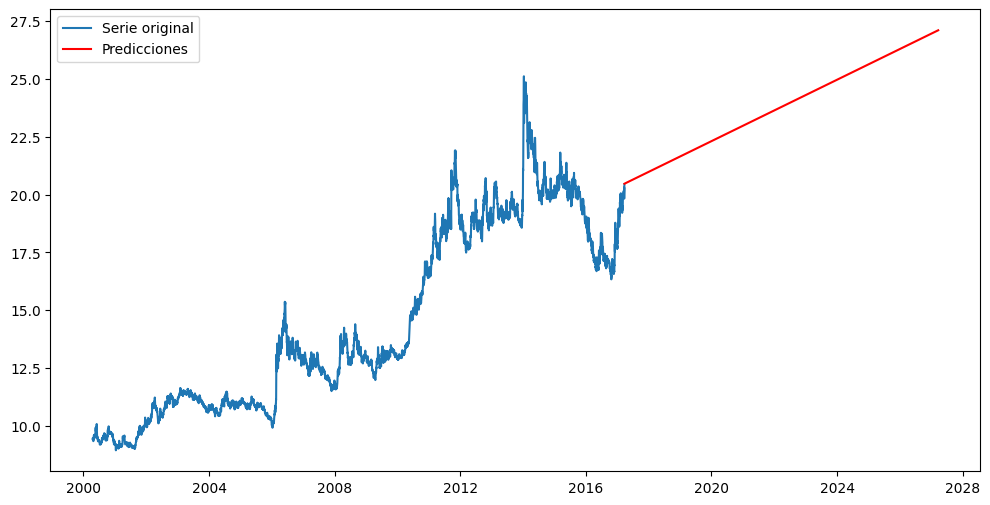

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(Dolar_ts, label="Serie original")
plt.plot(prediction_level.index, prediction_level, label="Predicciones", color='r')
plt.legend()
plt.show()

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
#arima necesita que no sea estacionario
model_sarima = SARIMAX(Dolar_ts,order=[1,1,2], seasonal_order=[1,1,1,12])
fit_sarima = model_sarima.fit()

#predecir
forecasted_sarima = fit_sarima.get_forecast(steps=nperiodos)
predicted_mean_sarima = forecasted_sarima.predicted_mean
conf_int_sarima = forecasted_sarima.conf_int()

print("Predicciones SARIMA")
print(predicted_mean_sarima)

print("Intervalos de confianza")
print(conf_int_sarima)



Predicciones SARIMA
2017-03-25    20.474954
2017-03-26    20.492438
2017-03-27    20.515894
2017-03-28    20.525709
2017-03-29    20.522719
                ...    
2027-03-18    27.136307
2027-03-19    27.147624
2027-03-20    27.151275
2027-03-21    27.160324
2027-03-22    27.178940
Freq: D, Name: predicted_mean, Length: 3650, dtype: float64
Intervalos de confianza
              lower y    upper y
2017-03-25  20.250359  20.699549
2017-03-26  20.165261  20.819614
2017-03-27  20.111709  20.920079
2017-03-28  20.056981  20.994437
2017-03-29  19.997320  21.048118
...               ...        ...
2027-03-18  -0.082886  54.355501
2027-03-19  -0.078994  54.374241
2027-03-20  -0.082764  54.385315
2027-03-21  -0.081165  54.401813
2027-03-22  -0.069998  54.427879

[3650 rows x 2 columns]


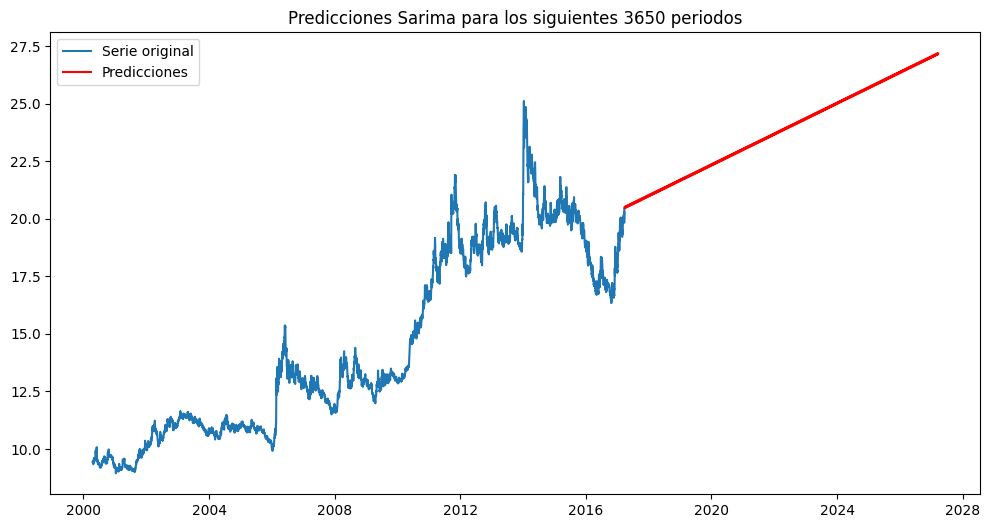

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(Dolar_ts, label="Serie original")
plt.plot(predicted_mean_sarima, label="Predicciones", color='r')
plt.title(f"Predicciones Sarima para los siguientes {nperiodos} periodos")
plt.legend()
plt.show()


### Evaluar el desempeño de los modelos utilizados

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

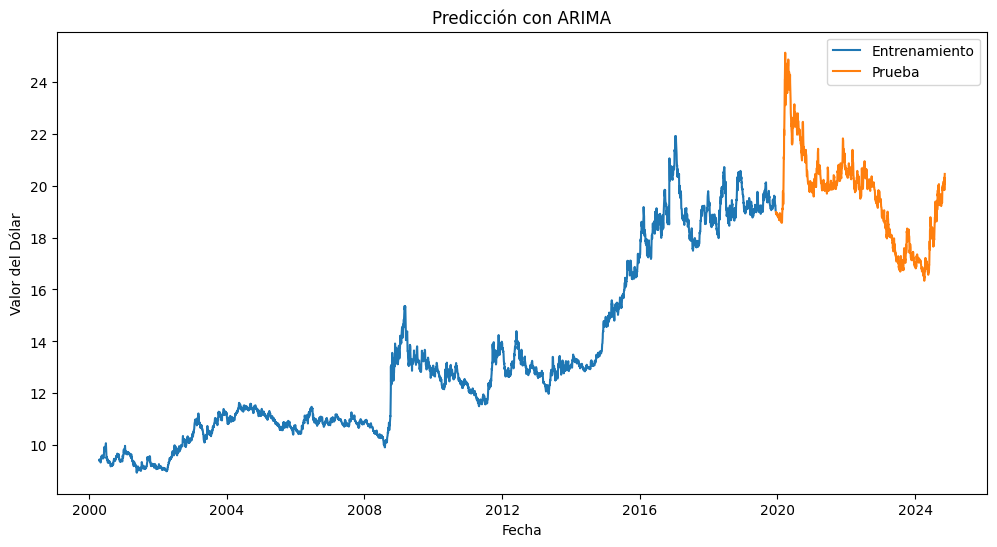

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Dividir en conjuntos de entrenamiento y prueba
train = df_Dolar['Precio_Dolar'][:int(0.8 * len(df_Dolar))]
test = df_Dolar['Precio_Dolar'][int(0.8 * len(df_Dolar)):]

# Modelo ARIMA
arima_model = ARIMA(train, order=(1,1,1))
arima_result = arima_model.fit()

# Predicciones con ARIMA
arima_pred = arima_result.predict(start=len(train), end=len(train) + len(test) - 1, typ="levels")

# Visualizar predicciones
plt.figure(figsize=(12, 6))
plt.plot(train, label="Entrenamiento")
plt.plot(test, label="Prueba")
#plt.plot(arima_pred, label="Predicción ARIMA", color='red')
plt.title("Predicción con ARIMA")
plt.xlabel("Fecha")
plt.ylabel("Valor del Dólar")
plt.legend()
plt.show()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/di

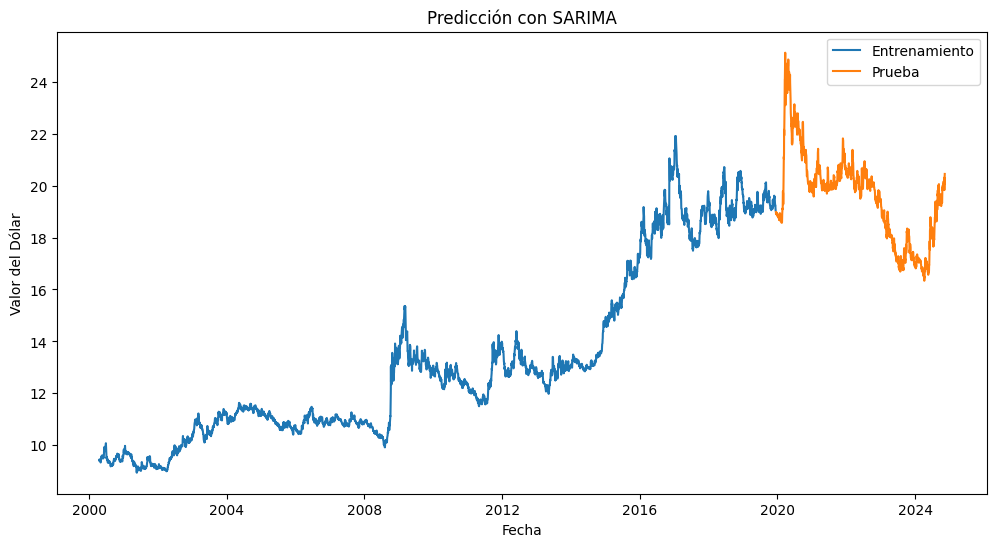

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Modelo SARIMA
sarima_model = SARIMAX(train, order=(1,1,1), seasonal_order=(2,2,2,12))
sarima_result = sarima_model.fit()

# Predicciones con SARIMA
sarima_pred = sarima_result.predict(start=len(train), end=len(train) + len(test) - 1, typ="levels")

# Visualización de predicciones
plt.figure(figsize=(12, 6))
plt.plot(train, label="Entrenamiento")
plt.plot(test, label="Prueba")
#plt.plot(sarima_pred, label="Predicción SARIMA", color='purple')
plt.title("Predicción con SARIMA")
plt.xlabel("Fecha")
plt.ylabel("Valor del Dólar")
plt.legend()
plt.show()

#4. Validación de Escenarios
###Validar los modelos en diferentes escenarios temporales.

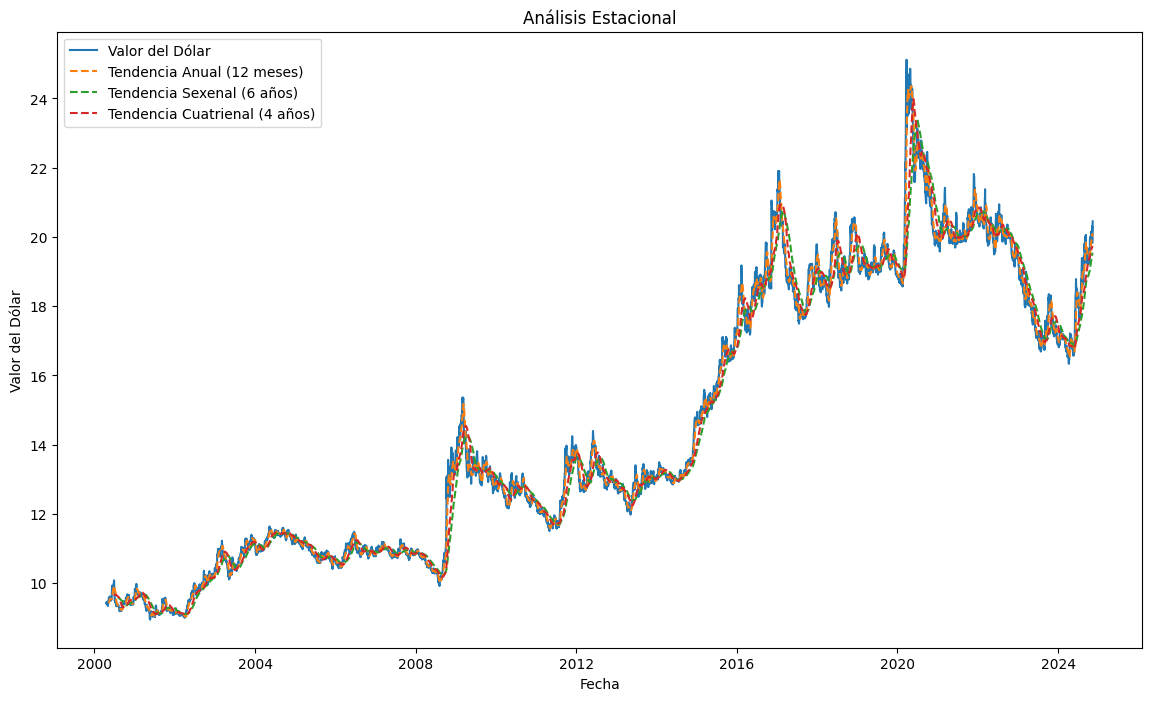

In [ ]:
# Resampleo para observar ciclos anuales, sexenales y cuatrienales
df_Dolar['Anual'] = df_Dolar['Precio_Dolar'].rolling(window=12).mean()       # Ciclo anual (12 meses)
df_Dolar['Sexenal'] = df_Dolar['Precio_Dolar'].rolling(window=72).mean()     # Ciclo sexenal (6 años = 72 meses)
df_Dolar['Cuatrienal'] = df_Dolar['Precio_Dolar'].rolling(window=48).mean()  # Ciclo cuatrienal (4 años = 48 meses)

plt.figure(figsize=(14, 8))
plt.plot(df_Dolar['Precio_Dolar'], label="Valor del Dólar")
plt.plot(df_Dolar['Anual'], label="Tendencia Anual (12 meses)", linestyle='--')
plt.plot(df_Dolar['Sexenal'], label="Tendencia Sexenal (6 años)", linestyle='--')
plt.plot(df_Dolar['Cuatrienal'], label="Tendencia Cuatrienal (4 años)", linestyle='--')
plt.title("Análisis Estacional")
plt.xlabel("Fecha")
plt.ylabel("Valor del Dólar")
plt.legend()
plt.show()

###Analizar si existen patrones estacionales o eventos recurrentes que afecten el valor del dólar frente al peso.

Podemos observar en las antriores graficas que se predice que el precio del dolar continuara aumentando hasta alcanzar los 27 pesos en el año 2027, mientras que para el 2024 estara por los 23 pesos, este tipo de prediccion hecha por el ARIMA Viene siendo potencialmente correcta , esto porque est modelo acepta que nuestro dataframe no sea estacionario, mientras que el SARIMA trabaja con modelos estacionarios lo que causa un margen de error
No existen Patrones Estacionales, esto lo vimos desde el principio cuando vimos que no existia un patron definido que se repitiera por ciertos periodos, el p_value es de 0.01 que al ser menor a 0.5 significa que no es estacionaria, los lags o veces que se va a comparar con los datos de atras es de 45, por lo que si hace una gran cantidad de comparaciones, lo que nos deja en claro que no hay un patron estacionario, Sin embargo tambien vemos que un factor como las elecciones, que son cada 6 años muestran un potencial crecimiento en el precio, pero no lo suficiente para ser un patron que se repetiria cada 6 años

#5. Informe y visualización
Como primeras observaciones podemos ver que desdxe un inicio los datos fueron muy variables no teniendo un patron fijo con el pasar de los años, porque vimos como la grafica se iba haciendo mas estrecha hasta el punto que no se notaba una diferencia en las graficas, tambien un problema que se tuvo a la hora de realizar los modelos es la cantidad de datos, pues la cantidad de datos existentes es de poco mas de 6000, con fechas salteadas, pero el modelo cuenta los datos con las fechas seguidas, y si una fecha no tiene un dato aun asi lo tomara, lo que creara un limite de datos que puede recibir el modelo, siendo el caso que solo acepta hasta 2017, porque el modelo pide un limite , este limite es la longitud , pero al añadir mas datos el limite no cambia y nos deja solo tomar hasta el 2017, aun asi pudimos ver que nuestro modelo entrenado tuvo ciertos aciertos con las predicciones, tambien con la ultima grafica de tres colores podemos ver el "Análisis Estacional" del valor del dólar desde el año 2000 hasta el 2024.

La línea azul representa el valor del dólar a lo largo del tiempo. Podemos ver picos y valles significativos, lo que indica fluctuaciones en su valor.
La línea amarilla muestra la tendencia a lo largo de un año, lo que puede ayudar a identificar patrones estacionales.
La línea verde muestra la tendencia sexenal, destacando patrones y ciclos a medio plazo.
La línea roja muestra la tendencia cuatrienal, ofreciendo una visión de ciclos más cortos en comparación con la línea verde.
Picos y valles: La gráfica tiene varios picos (máximos) y valles (mínimos) que indican fluctuaciones importantes que pueden estar relacionadas con eventos económicos, políticos, o cambios en la política monetaria.

PREDICCIONES
Tendencia Anual (12 meses): Si la línea amarilla muestra un patrón ascendente o descendente claro en el último año, podemos extrapolar esta tendencia hacia adelante en el corto plazo.
Tendencia Sexenal (6 años): La línea verde puede ayudar a identificar ciclos más amplios. Si ha habido un ciclo creciente o decreciente en los últimos 6 años, podríamos esperar que esta tendencia continúe, especialmente si se alinea con los patrones históricos observados.
Tendencia Cuatrienal (4 años): La línea roja puede mostrar ciclos más cortos. Si esta tendencia muestra un aumento o disminución en los últimos 4 años, podríamos ver un reflejo similar en el próximo par de años.

Proyecciones Basadas en Tendencias:
Corto Plazo: Dependiendo de la línea amarilla, si ha habido un aumento constante, podríamos esperar que el dólar siga subiendo ligeramente en el próximo año.
Mediano Plazo: Si la línea verde muestra un ciclo creciente, es probable que esta tendencia continúe en los próximos años hasta alcanzar un nuevo pico antes de potencialmente estabilizarse o descender.
Largo Plazo: La línea roja puede indicar patrones más estables o cíclicos. Si muestra una tendencia ascendente, el dólar podría mantener una trayectoria similar.



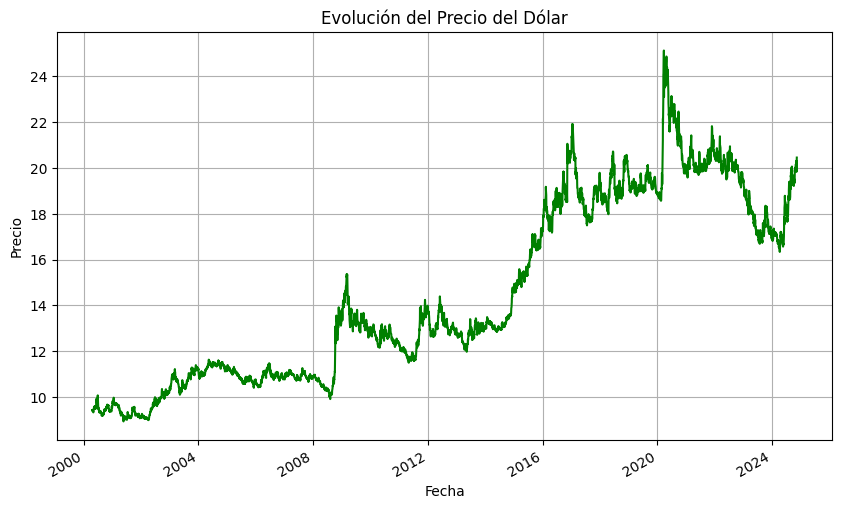

In [ ]:
df_Dolar['Precio_Dolar'].plot(figsize=(10, 6), title='Evolución del Precio del Dólar', color='green')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.grid()
plt.show()

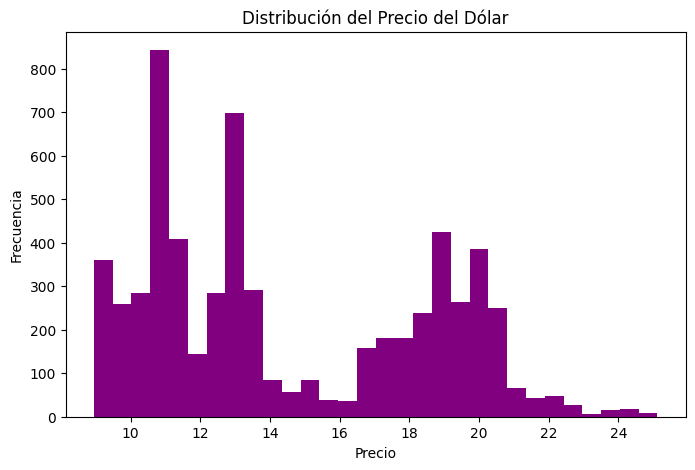

In [ ]:
df_Dolar['Precio_Dolar'].hist(bins=30, figsize=(8, 5), color='purple')
plt.title('Distribución de datos Precio del Dólar')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.grid()
plt.show()

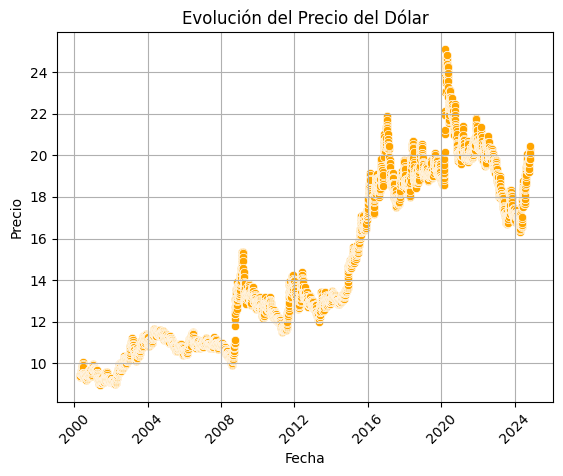

In [ ]:
import seaborn as sns

sns.scatterplot(x=df_Dolar.index, y=df_Dolar['Precio_Dolar'], color='orange')
plt.title('Precio del dolar')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.xticks(rotation=45)
plt.grid()
plt.show()